In [ ]:
# Bellabeat Case Study: Activity & Sleep Analysis

## Project Overview
This project analyzes Fitbit user data to understand patterns in daily activity and sleep behavior. The goal is to generate insights that can inform Bellabeat’s marketing strategy and product development.

## Business Task
Analyze smart device usage data to identify trends in user behavior and provide recommendations for improving user engagement.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
## Data Loading

The dataset includes daily activity and sleep tracking data from Fitbit users.

In [3]:
df1 = pd.read_csv("mturkfitbit_export_3.12.16-4.11.16/dailyActivity_merged.csv")

df2 = pd.read_csv("mturkfitbit_export_4.12.16-5.12.16/dailyActivity_merged.csv")

In [4]:
df1.shape, df2.shape

((457, 15), (940, 15))

In [5]:
df1.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [6]:
df2.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [7]:
daily_activity = pd.concat([df1, df2], ignore_index=True)

In [8]:
daily_activity.duplicated().sum()

np.int64(0)

In [9]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [10]:
daily_activity.shape

(1397, 15)

In [11]:
daily_activity.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

In [12]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [13]:
daily_activity.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,1.397000e+03,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000
mean,4.781210e+09,7280.898354,5.219434,5.192219,0.131481,1.397416,0.538461,3.193407,0.001704,19.679313,13.403006,185.372942,992.542591,2266.265569
std,2.384293e+09,5214.336113,3.994206,3.980077,0.703683,2.607480,0.867436,2.116869,0.007736,31.675878,26.401247,114.058601,313.297376,753.005527
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3146.000000,2.170000,2.160000,0.000000,0.000000,0.000000,1.610000,0.000000,0.000000,0.000000,111.000000,729.000000,1799.000000
50%,4.445115e+09,6999.000000,4.950000,4.950000,0.000000,0.100000,0.200000,3.240000,0.000000,2.000000,6.000000,195.000000,1057.000000,2114.000000
75%,6.962181e+09,10544.000000,7.500000,7.480000,0.000000,1.830000,0.770000,4.690000,0.000000,30.000000,18.000000,262.000000,1244.000000,2770.000000
max,8.877689e+09,36019.000000,28.030001,28.030001,6.727057,21.920000,6.480000,12.510000,0.110000,210.000000,660.000000,720.000000,1440.000000,4900.000000


In [14]:
daily_activity["TotalSteps"].mean()

np.float64(7280.898353614889)

In [15]:
daily_activity["SedentaryMinutes"].mean()

np.float64(992.5425912670007)

In [16]:
daily_activity["VeryActiveMinutes"].mean()

np.float64(19.67931281317108)

In [17]:
def activity_level(steps):
    if steps < 5000:
        return "Sedentary"
    elif steps < 7500:
        return "Lightly Active"
    elif steps < 10000:
        return "Moderately Active"
    else:
        return "Very Active"

In [18]:
daily_activity["ActivityLevel"] = daily_activity["TotalSteps"].apply(activity_level)

In [19]:
daily_activity["ActivityLevel"].value_counts()

ActivityLevel
Sedentary            500
Very Active          430
Lightly Active       254
Moderately Active    213
Name: count, dtype: int64

In [20]:
daily_activity["Id"].nunique()

35

In [21]:
daily_activity["Id"].value_counts().head()

Id
4020332650    63
1503960366    50
1624580081    50
4702921684    46
4445114986    46
Name: count, dtype: int64

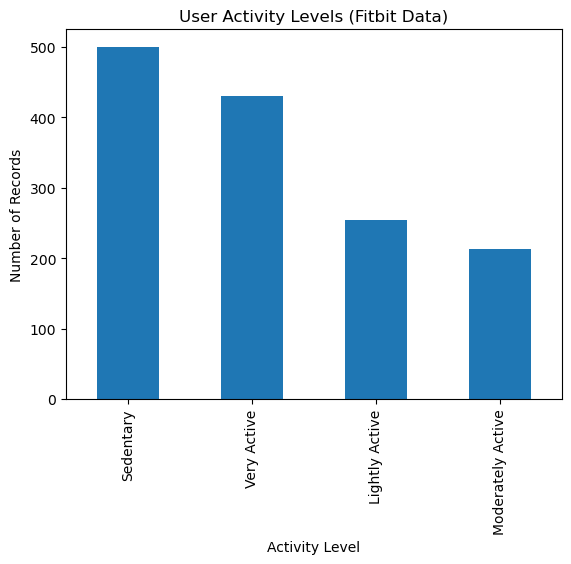

In [22]:
daily_activity["ActivityLevel"].value_counts().plot(kind="bar")

plt.title("User Activity Levels (Fitbit Data)")
plt.xlabel("Activity Level")
plt.ylabel("Number of Records")
plt.show()

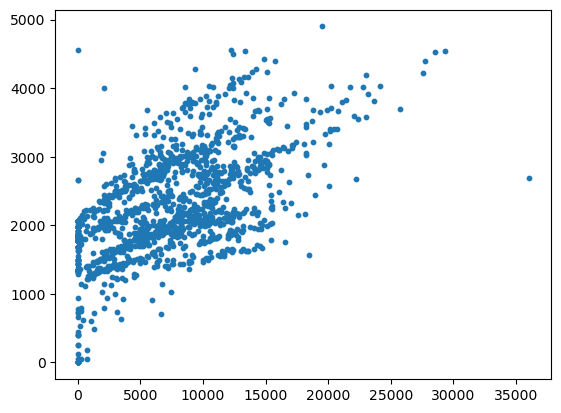

In [23]:
plt.scatter(daily_activity["TotalSteps"], daily_activity["Calories"], s=10)

In [28]:
sleep = pd.read_csv("mturkfitbit_export_4.12.16-5.12.16/sleepDay_merged.csv")

In [29]:
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [30]:
sleep.shape

(413, 5)

In [31]:
sleep.duplicated().sum()

np.int64(3)

In [32]:
sleep = sleep.drop_duplicates()

In [33]:
sleep = sleep.rename(columns={
    "TotalMinutesAsleep": "MinutesAsleep",
    "TotalTimeInBed": "TimeInBed"
})

In [34]:
sleep["HoursAsleep"] = sleep["MinutesAsleep"] / 60

In [35]:
sleep["MinutesAsleep"].mean()

np.float64(419.17317073170733)

In [36]:
sleep[["MinutesAsleep", "TimeInBed"]].describe()

,MinutesAsleep,TimeInBed
count,410.000000,410.000000
mean,419.173171,458.482927
std,118.635918,127.455140
min,58.000000,61.000000
25%,361.000000,403.750000
50%,432.500000,463.000000
75%,490.000000,526.000000
max,796.000000,961.000000


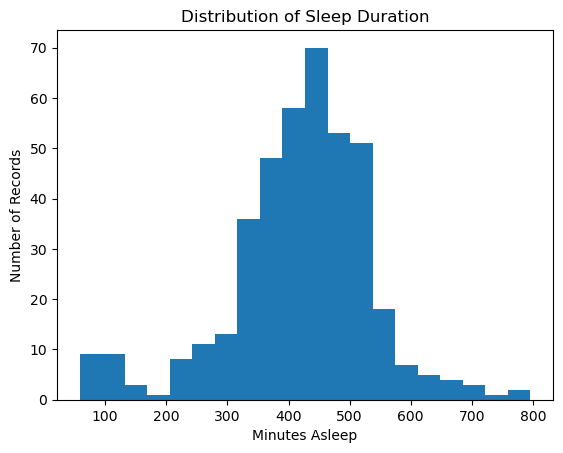

In [37]:
import matplotlib.pyplot as plt

plt.hist(sleep["MinutesAsleep"], bins=20)
plt.title("Distribution of Sleep Duration")
plt.xlabel("Minutes Asleep")
plt.ylabel("Number of Records")
plt.show()

In [38]:
sleep.describe()

,Id,TotalSleepRecords,MinutesAsleep,TimeInBed,HoursAsleep
count,4.100000e+02,410.000000,410.000000,410.000000,410.000000
mean,4.994963e+09,1.119512,419.173171,458.482927,6.986220
std,2.060863e+09,0.346636,118.635918,127.455140,1.977265
min,1.503960e+09,1.000000,58.000000,61.000000,0.966667
25%,3.977334e+09,1.000000,361.000000,403.750000,6.016667
50%,4.702922e+09,1.000000,432.500000,463.000000,7.208333
75%,6.962181e+09,1.000000,490.000000,526.000000,8.166667
max,8.792010e+09,3.000000,796.000000,961.000000,13.266667


In [39]:
sleep_activity = pd.merge(daily_activity, sleep, on="Id")

In [40]:
sleep_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,ActivityLevel,SleepDay,TotalSleepRecords,MinutesAsleep,TimeInBed,HoursAsleep
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,...,12,205,804,1819,Very Active,4/12/2016 12:00:00 AM,1,327,346,5.450000
1,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,...,12,205,804,1819,Very Active,4/13/2016 12:00:00 AM,2,384,407,6.400000
2,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,...,12,205,804,1819,Very Active,4/15/2016 12:00:00 AM,1,412,442,6.866667
3,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,...,12,205,804,1819,Very Active,4/16/2016 12:00:00 AM,2,340,367,5.666667
4,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,...,12,205,804,1819,Very Active,4/17/2016 12:00:00 AM,1,700,712,11.666667


In [ ]:
## Sleep vs Activity Relationship

Exploring whether activity levels influence sleep duration.

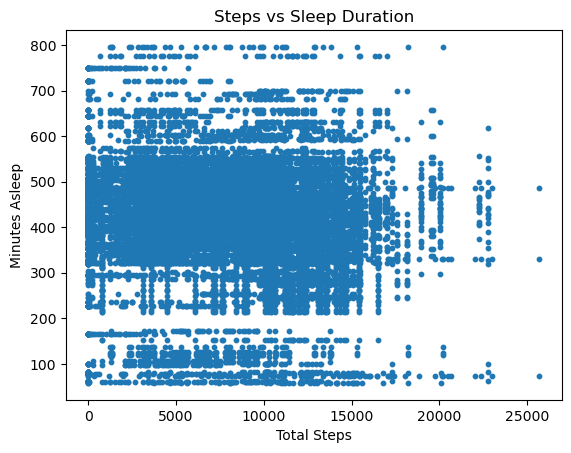

In [41]:
import matplotlib.pyplot as plt

plt.scatter(
    sleep_activity["TotalSteps"],
    sleep_activity["MinutesAsleep"],
    s=10  # smaller dots
)

plt.title("Steps vs Sleep Duration")
plt.xlabel("Total Steps")
plt.ylabel("Minutes Asleep")
plt.show()

In [ ]:
## Key Insights

- Users spend a significant portion of their time sedentary
- Activity patterns include bursts of high activity rather than consistent movement
- Average sleep duration is around 7 hours but varies widely
- No strong relationship between activity/ sleep behavior

In [ ]:
## Recommendations

- Integrate sleep + activity tracking into unified wellness insights
- Provide personalized recommendations based on behavior patterns
- Encourage habit-building for both movement and sleep consistency
- Segment users based on lifestyle patterns for targeted engagement
